# Churn 예측 모델링 - Tuning & Ensemble

이 노트북은 `04_churn_modeling_baseline.ipynb` 이후 단계다. 목적은 단일 split 결과에만 의존하지 않고, `StratifiedKFold` 기반 교차검증과 튜닝, Voting, Stacking으로 성능 개선 가능성을 확인하는 것이다.

진행 순서는 다음과 같다.

1. v2 데이터 로드 및 동일한 train/test split 구성
2. `StratifiedKFold`로 baseline 후보의 CV 성능 확인
3. Logistic Regression은 작은 `GridSearchCV`, 부스팅 모델은 `RandomizedSearchCV`로 튜닝
4. best estimator를 holdout test set에서 비교
5. Soft Voting과 Stacking을 추가 실험
6. 최종 후보에 대해 threshold를 다시 조정

주의: test set은 최종 비교용으로만 사용한다. 튜닝과 모델 선택은 train set 내부의 CV에서 진행한다.

## 1. 라이브러리 로드

튜닝과 앙상블에 필요한 라이브러리를 불러온다. 부스팅 라이브러리는 설치된 후보만 사용한다.

In [1]:
from pathlib import Path
import warnings

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.stats import randint, uniform, loguniform

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5

font_candidates = ['AppleGothic', 'NanumGothic', 'Malgun Gothic']
available_fonts = {font.name for font in fm.fontManager.ttflist}
font_name = next((font for font in font_candidates if font in available_fonts), None)
if font_name:
    plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')


def make_ohe(**kwargs):
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False, **kwargs)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False, **kwargs)

## 2. 데이터와 전처리 준비

`04`와 같은 데이터, 같은 split 기준을 사용한다. 그래야 baseline 노트북의 holdout 결과와 비교가 가능하다.

In [2]:
data_candidates = [
    Path('data/user_behavior_50000/netflix_user_behavior_churn_50000v2.csv'),
    Path('../data/user_behavior_50000/netflix_user_behavior_churn_50000v2.csv'),
]
data_path = next(path for path in data_candidates if path.exists())

df = pd.read_csv(data_path)
X = df.drop(columns=['user_id', 'churned'])
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train churn ratio:', round(y_train.mean(), 4))
print('Test churn ratio:', round(y_test.mean(), 4))

Train shape: (40000, 18) Test shape: (10000, 18)
Train churn ratio: 0.2093
Test churn ratio: 0.2093


**Split 재확인 해석**

- `04`와 동일하게 train 40,000명, test 10,000명으로 분리되었다.
- train/test의 churn 비율이 모두 약 20.93%로 유지되었으므로, stratified split이 의도대로 적용되었다.
- 이 노트북의 test 결과는 `04`의 baseline 결과와 직접 비교할 수 있다. 같은 split을 유지했기 때문에 튜닝/앙상블으로 인한 변화만 비교할 수 있다.

In [3]:
def build_preprocessor(numeric_cols=numeric_features, categorical_cols=categorical_features):
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', make_ohe(), categorical_cols),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )


def get_scores(model, X_eval):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_eval)[:, 1]
    raw_scores = model.decision_function(X_eval)
    return (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())


def evaluate_predictions(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
    }


def evaluate_model(name, model, X_eval, y_eval, threshold=0.5):
    y_score = get_scores(model, X_eval)
    metrics = evaluate_predictions(y_eval, y_score, threshold=threshold)
    row = {k: v for k, v in metrics.items() if k != 'confusion_matrix'}
    row['model'] = name
    return row, metrics['confusion_matrix'], y_score


def make_pipeline(estimator):
    return Pipeline([
        ('preprocess', build_preprocessor()),
        ('model', estimator),
    ])

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
}

## 3. Stratified K-Fold CV 모델 비교

단일 train/test split만 보면 결과가 우연에 영향을 받을 수 있다. 먼저 stratified CV로 모델별 평균 성능과 변동성을 확인한다.

In [4]:
def make_boosting_estimators(y_train):
    estimators = {}

    try:
        from lightgbm import LGBMClassifier
        estimators['LightGBM'] = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    except Exception as exc:
        print('LightGBM unavailable:', exc)

    try:
        from xgboost import XGBClassifier
        neg, pos = np.bincount(y_train)
        estimators['XGBoost'] = XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric='logloss',
            scale_pos_weight=neg / pos,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    except Exception as exc:
        print('XGBoost unavailable:', exc)

    try:
        from catboost import CatBoostClassifier
        estimators['CatBoost'] = CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function='Logloss',
            auto_class_weights='Balanced',
            random_seed=RANDOM_STATE,
            verbose=False,
        )
    except Exception as exc:
        print('CatBoost unavailable:', exc)

    return estimators

candidate_estimators = {
    'DummyClassifier': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=3,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}
candidate_estimators.update(make_boosting_estimators(y_train))

cv_rows = []
for name, estimator in candidate_estimators.items():
    pipe = make_pipeline(estimator)
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    row = {'model': name}
    for metric in scoring:
        row[f'{metric}_mean'] = scores[f'test_{metric}'].mean()
        row[f'{metric}_std'] = scores[f'test_{metric}'].std()
    cv_rows.append(row)

cv_result = pd.DataFrame(cv_rows).set_index('model')
cv_result.sort_values(['pr_auc_mean', 'f1_mean', 'recall_mean'], ascending=False)

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
model,,,,,,,,,,,,
LogisticRegression,0.830325,0.004604,0.563900,0.007628,0.835263,0.011310,0.673250,0.008474,0.911108,0.004193,0.761310,0.009907
CatBoost,0.834625,0.004227,0.572983,0.007418,0.823915,0.008488,0.675894,0.007345,0.909634,0.004316,0.758582,0.010862
XGBoost,0.833150,0.002650,0.570188,0.004838,0.823796,0.008031,0.673899,0.004573,0.908549,0.004409,0.755601,0.010419
LightGBM,0.836725,0.003142,0.579147,0.005512,0.804325,0.010375,0.673391,0.006476,0.906293,0.004424,0.752150,0.011000
RandomForestClassifier,0.864700,0.002589,0.680928,0.007120,0.665272,0.008074,0.672983,0.006377,0.901484,0.003803,0.734608,0.010669
DummyClassifier,0.790725,0.000050,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.209275,0.000050


**Stratified K-Fold 결과 해석**

- 5-fold CV의 PR AUC 평균 기준으로는 `LogisticRegression`이 0.7613으로 가장 높다.
- `CatBoost`는 PR AUC 0.7586, `XGBoost`는 0.7556, `LightGBM`은 0.7522로 Logistic Regression보다 낮았다.
- recall 기준으로도 `LogisticRegression`이 0.8353으로 가장 높다. 이탈 고객을 최대한 놓치지 않는 목적에는 여전히 강한 기준선이다.
- `RandomForestClassifier`는 accuracy 평균이 0.8647로 가장 높지만 recall은 0.6653으로 낮다. 유지 고객을 잘 맞추면서 이탈 고객 일부를 놓치는 방향으로 작동한다.
- `DummyClassifier`는 accuracy가 0.7907이지만 recall과 f1이 0이다. 클래스 불균형 상황에서 accuracy만 보면 안 되는 이유를 다시 보여준다.
- fold 간 표준편차는 주요 모델의 PR AUC 기준 약 0.01 수준이다. 모델 간 PR AUC 차이도 0.003~0.009 정도라서, 아주 큰 성능 차이라고 보기는 어렵다.

정리하면, CV 단계에서는 복잡한 부스팅 모델이 선형 모델을 명확히 이기지 못했다. 따라서 이후 튜닝/앙상블은 “성능을 크게 뒤집는지”보다 “작지만 안정적인 개선이 있는지”를 확인하는 실험에 가깝다.

**CV 해석**

평균 성능뿐 아니라 표준편차도 본다. 평균 PR AUC가 높아도 fold 간 편차가 크면 안정적인 모델이라고 보기 어렵다. 이후 튜닝은 CV 결과에서 유망한 모델을 중심으로 진행한다.

## 4. GridSearchCV - Logistic Regression

Logistic Regression은 파라미터 공간이 작으므로 GridSearchCV가 적합하다. 여기서는 `C`와 class weight를 중심으로 비교한다.

In [5]:
print('[GridSearch] LogisticRegression start')
print('Param grid:')
print({
    'model__C': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
    'model__class_weight': [None, 'balanced'],
})
print(f'Total fits: {7 * 2 * N_SPLITS}')

logistic_search = GridSearchCV(
    estimator=make_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    param_grid={
        'model__C': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
        'model__class_weight': [None, 'balanced'],
    },
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=2,
)
logistic_search.fit(X_train, y_train)

print('[GridSearch] LogisticRegression done')
print('Best params:', logistic_search.best_params_)
print('Best CV PR AUC:', round(logistic_search.best_score_, 6))

[GridSearch] LogisticRegression start
Param grid:
{'model__C': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0], 'model__class_weight': [None, 'balanced']}
Total fits: 70
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV] END ............model__C=0.01, model__class_weight=None; total time=   0.6s
[CV] END ............model__C=0.01, model__class_weight=None; total time=   0.7s
[CV] END ............model__C=0.01, model__class_weight=None; total time=   0.7s
[CV] END ............model__C=0.01, model__class_weight=None; total time=   0.8s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=   1.3s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=   1.3s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=   1.4s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=   1.4s
[CV] END ............model__C=0.03, model__class_weight=None; total time=   1.3s
[CV] END ............model__C=0.03, model__class_

**Logistic Regression GridSearch 해석**

- Logistic Regression은 `C` 7개와 `class_weight` 2개를 조합해 총 14개 후보를 탐색했다.
- 5-fold CV를 적용했으므로 총 70번 학습이 수행되었다.
- 최적 조합은 `C=0.1`, `class_weight='balanced'`였다.
- best CV PR AUC는 0.7613으로, 기본 Logistic Regression CV 결과와 거의 같다. 즉, 넓은 개선보다는 기존 설정을 확인하고 조금 안정화한 수준이다.
- `class_weight='balanced'`가 선택된 것은 churned=1 비율이 약 20.9%인 상황에서 양성 클래스 탐지를 더 중요하게 보는 현재 목표와 일관적이다.

## 5. RandomizedSearchCV - 부스팅 모델

부스팅 모델은 파라미터 조합이 많아 넓은 GridSearchCV보다 RandomizedSearchCV가 현실적이다. 먼저 넓게 탐색하고, 필요하면 결과 주변에서 좁은 GridSearchCV를 추가한다.

In [6]:
def build_boosting_searches(y_train):
    searches = {}

    try:
        from lightgbm import LGBMClassifier
        lgbm_pipe = make_pipeline(LGBMClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ))
        searches['LightGBM_RandomizedSearch'] = RandomizedSearchCV(
            estimator=lgbm_pipe,
            param_distributions={
                'model__n_estimators': randint(200, 800),
                'model__learning_rate': loguniform(0.01, 0.12),
                'model__num_leaves': randint(16, 64),
                'model__min_child_samples': randint(10, 80),
                'model__subsample': uniform(0.7, 0.3),
                'model__colsample_bytree': uniform(0.7, 0.3),
            },
            n_iter=25,
            scoring='average_precision',
            cv=cv,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            refit=True,
            verbose=2,
        )
        print('[search candidate] LightGBM_RandomizedSearch added | total fits:', 25 * N_SPLITS)
    except Exception as exc:
        print('[search candidate] LightGBM search unavailable:', exc)

    try:
        from xgboost import XGBClassifier
        neg, pos = np.bincount(y_train)
        xgb_pipe = make_pipeline(XGBClassifier(
            eval_metric='logloss',
            scale_pos_weight=neg / pos,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ))
        searches['XGBoost_RandomizedSearch'] = RandomizedSearchCV(
            estimator=xgb_pipe,
            param_distributions={
                'model__n_estimators': randint(200, 800),
                'model__learning_rate': loguniform(0.01, 0.12),
                'model__max_depth': randint(3, 8),
                'model__min_child_weight': randint(1, 8),
                'model__subsample': uniform(0.7, 0.3),
                'model__colsample_bytree': uniform(0.7, 0.3),
            },
            n_iter=25,
            scoring='average_precision',
            cv=cv,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            refit=True,
            verbose=2,
        )
        print('[search candidate] XGBoost_RandomizedSearch added | total fits:', 25 * N_SPLITS)
    except Exception as exc:
        print('[search candidate] XGBoost search unavailable:', exc)

    return searches

boosting_searches = build_boosting_searches(y_train)
print('Searches to run:', list(boosting_searches.keys()))
boosting_searches.keys()

[search candidate] LightGBM_RandomizedSearch added | total fits: 125
[search candidate] XGBoost_RandomizedSearch added | total fits: 125
Searches to run: ['LightGBM_RandomizedSearch', 'XGBoost_RandomizedSearch']


dict_keys(['LightGBM_RandomizedSearch', 'XGBoost_RandomizedSearch'])

**부스팅 RandomizedSearch 후보 해석**

- 실행 가능한 부스팅 튜닝 후보는 `LightGBM_RandomizedSearch`, `XGBoost_RandomizedSearch` 두 개다.
- 각 모델은 `n_iter=25`, `cv=5`이므로 모델당 125번 학습한다.
- 두 모델을 모두 돌리면 총 250번의 부스팅 모델 학습이 발생한다. 이 노트북에서 시간이 오래 걸리는 가장 큰 이유다.
- 튜닝 평가지표는 `average_precision`, 즉 PR AUC다. 이탈 고객을 양성 클래스로 볼 때 적절한 선택이다.

In [7]:
search_results = []
tuned_models = {
    'LogisticRegression_GridSearch': logistic_search.best_estimator_,
}

print('[Search Summary] LogisticRegression_GridSearch already fitted')
print('  Best CV PR AUC:', round(logistic_search.best_score_, 6))
print('  Best params:', logistic_search.best_params_)
print('-' * 80)

for idx, (name, search) in enumerate(boosting_searches.items(), start=1):
    print(f'[{idx}/{len(boosting_searches)}] Start search: {name}', flush=True)
    print(f'  n_iter={search.n_iter}, cv_splits={N_SPLITS}, total_fits={search.n_iter * N_SPLITS}', flush=True)
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    search_results.append({
        'search': name,
        'best_cv_pr_auc': search.best_score_,
        'best_params': search.best_params_,
    })
    print(f'[{idx}/{len(boosting_searches)}] Done search: {name}', flush=True)
    print('  Best CV PR AUC:', round(search.best_score_, 6), flush=True)
    print('  Best params:', search.best_params_, flush=True)
    print('-' * 80, flush=True)

search_summary = pd.DataFrame([
    {
        'search': 'LogisticRegression_GridSearch',
        'best_cv_pr_auc': logistic_search.best_score_,
        'best_params': logistic_search.best_params_,
    },
    *search_results,
])
search_summary

[Search Summary] LogisticRegression_GridSearch already fitted
  Best CV PR AUC: 0.761317
  Best params: {'model__C': 0.1, 'model__class_weight': 'balanced'}
--------------------------------------------------------------------------------
[1/2] Start search: LightGBM_RandomizedSearch
  n_iter=25, cv_splits=5, total_fits=125
Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END model__colsample_bytree=0.8123620356542087, model__learning_rate=0.10616785666328349, model__min_child_samples=70, model__n_estimators=220, model__num_leaves=54, model__subsample=0.8337498258560773; total time= 1.0min
[CV] END model__colsample_bytree=0.8123620356542087, model__learning_rate=0.10616785666328349, model__min_child_samples=70, model__n_estimators=220, model__num_leaves=54, model__subsample=0.8337498258560773; total time= 1.0min
[CV] END model__colsample_bytree=0.8123620356542087, model__learning_rate=0.10616785666328349, model__min_child_samples=70, model__n_estimators=220, model__num

,search,best_cv_pr_auc,best_params
0,LogisticRegression_GridSearch,0.761317,"{'model__C': 0.1, 'model__class_weight': 'bala..."
1,LightGBM_RandomizedSearch,0.755316,{'model__colsample_bytree': 0.8773893363123181...
2,XGBoost_RandomizedSearch,0.758653,{'model__colsample_bytree': 0.7816396748153905...


**RandomizedSearch 결과 해석**

- `LogisticRegression_GridSearch`의 best CV PR AUC는 0.7613이다.
- `LightGBM_RandomizedSearch`의 best CV PR AUC는 0.7553으로, 튜닝 후에도 Logistic Regression보다 낮았다.
- `XGBoost_RandomizedSearch`의 best CV PR AUC는 0.7587로 LightGBM보다 높지만, Logistic Regression보다는 낮았다.
- 이 결과만 보면 train 내부 CV에서는 Logistic Regression이 가장 안정적인 후보이고, XGBoost는 test set에서 추가 확인할 가치가 있는 2순위 후보로 볼 수 있다.
- 부스팅 모델이 기대보다 크게 앞서지 못한 이유는 데이터의 churn 패턴이 선형 조합만으로도 상당히 잘 설명되거나, 현재 피처 수와 데이터 구조에서 복잡한 비선형 모델의 추가 이득이 제한적이기 때문일 수 있다.

## 6. Holdout Test 평가

튜닝은 train 내부 CV에서 끝냈고, 이제 holdout test set으로 최종 후보 성능을 비교한다. 이 표는 baseline 노트북의 test 결과와 함께 해석하면 된다.

In [8]:
holdout_rows = []
holdout_confusions = {}
holdout_scores = {}

print('[Holdout] Start tuned model evaluation')
for idx, (name, model) in enumerate(tuned_models.items(), start=1):
    print(f'[{idx}/{len(tuned_models)}] Evaluate holdout: {name}', flush=True)
    row, cm, y_score = evaluate_model(name, model, X_test, y_test)
    holdout_rows.append(row)
    holdout_confusions[name] = cm
    holdout_scores[name] = y_score
    print(
        f"[{idx}/{len(tuned_models)}] Done: {name} | "
        f"PR AUC={row['pr_auc']:.4f}, F1={row['f1']:.4f}, "
        f"Recall={row['recall']:.4f}, Precision={row['precision']:.4f}",
        flush=True,
    )
print('[Holdout] Done tuned model evaluation')

holdout_result = pd.DataFrame(holdout_rows).set_index('model')
holdout_result.sort_values(['pr_auc', 'f1', 'recall'], ascending=False)

[Holdout] Start tuned model evaluation
[1/3] Evaluate holdout: LogisticRegression_GridSearch
[1/3] Done: LogisticRegression_GridSearch | PR AUC=0.7631, F1=0.6733, Recall=0.8213, Precision=0.5705
[2/3] Evaluate holdout: LightGBM_RandomizedSearch
[2/3] Done: LightGBM_RandomizedSearch | PR AUC=0.7587, F1=0.6721, Recall=0.8113, Precision=0.5736
[3/3] Evaluate holdout: XGBoost_RandomizedSearch
[3/3] Done: XGBoost_RandomizedSearch | PR AUC=0.7637, F1=0.6732, Recall=0.8146, Precision=0.5737
[Holdout] Done tuned model evaluation


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
XGBoost_RandomizedSearch,0.5,0.8345,0.573688,0.814620,0.673248,0.905117,0.763671
LogisticRegression_GridSearch,0.5,0.8332,0.570528,0.821309,0.673325,0.906560,0.763136
LightGBM_RandomizedSearch,0.5,0.8343,0.573649,0.811276,0.672076,0.902998,0.758715


**Holdout Test 결과 해석**

- holdout test 기준 PR AUC는 `XGBoost_RandomizedSearch`가 0.7637로 가장 높다.
- `LogisticRegression_GridSearch`는 PR AUC 0.7631, recall 0.8213으로 거의 같은 수준이며, recall은 가장 높다.
- `LightGBM_RandomizedSearch`는 PR AUC 0.7587로 세 후보 중 가장 낮다.
- 세 모델의 f1은 모두 약 0.672~0.673으로 매우 비슷하다. 성능 차이가 작기 때문에 단순히 숫자 0.0005 차이만으로 모델을 강하게 주장하기는 어렵다.
- test에서는 XGBoost가 PR AUC 기준 Logistic Regression을 아주 조금 앞섰지만, Logistic Regression은 해석 가능성과 recall 측면에서 여전히 강한 후보다.

이 단계의 결론은 “튜닝된 XGBoost가 PR AUC를 소폭 개선했지만, Logistic Regression을 완전히 대체할 만큼 큰 차이는 아니다”로 보는 것이 적절하다.

## 7. Soft Voting

Soft Voting은 여러 모델의 예측 확률을 평균낸다. 서로 다른 성격의 모델을 조합할 때 의미가 있다. 여기서는 튜닝된 Logistic Regression과 가장 좋은 부스팅 모델을 중심으로 구성한다.

In [9]:
best_tuned_name = holdout_result.sort_values(['pr_auc', 'f1', 'recall'], ascending=False).index[0]
best_tuned_model = tuned_models[best_tuned_name]

voting_members = [('lr', tuned_models['LogisticRegression_GridSearch'])]
for name, model in tuned_models.items():
    if name != 'LogisticRegression_GridSearch':
        voting_members.append((name.lower().replace('_randomizedsearch', ''), model))

print('[SoftVoting] Members:', [name for name, _ in voting_members])
print('[SoftVoting] Fit start')
soft_voting = VotingClassifier(
    estimators=voting_members,
    voting='soft',
    n_jobs=-1,
)
soft_voting.fit(X_train, y_train)
print('[SoftVoting] Fit done')

voting_row, voting_cm, voting_score = evaluate_model('SoftVoting', soft_voting, X_test, y_test)
print(
    '[SoftVoting] Holdout | '
    f"PR AUC={voting_row['pr_auc']:.4f}, F1={voting_row['f1']:.4f}, "
    f"Recall={voting_row['recall']:.4f}, Precision={voting_row['precision']:.4f}"
)
voting_result = pd.DataFrame([voting_row]).set_index('model')
pd.concat([holdout_result, voting_result]).sort_values(['pr_auc', 'f1', 'recall'], ascending=False)

[SoftVoting] Members: ['lr', 'lightgbm', 'xgboost']
[SoftVoting] Fit start


[SoftVoting] Fit done
[SoftVoting] Holdout | PR AUC=0.7639, F1=0.6743, Recall=0.8161, Precision=0.5745


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
SoftVoting,0.5,0.8350,0.574504,0.816054,0.674299,0.905820,0.763909
XGBoost_RandomizedSearch,0.5,0.8345,0.573688,0.814620,0.673248,0.905117,0.763671
LogisticRegression_GridSearch,0.5,0.8332,0.570528,0.821309,0.673325,0.906560,0.763136
LightGBM_RandomizedSearch,0.5,0.8343,0.573649,0.811276,0.672076,0.902998,0.758715


**Soft Voting 결과 해석**

- Soft Voting은 Logistic Regression, LightGBM, XGBoost의 예측 확률을 결합했다.
- holdout PR AUC는 0.7639로, 단일 XGBoost의 0.7637보다 아주 조금 높다.
- f1도 0.6743으로 단일 모델들보다 소폭 개선되었다.
- recall은 0.8161로 Logistic Regression보다는 낮지만 XGBoost보다는 약간 높고, precision은 0.5745로 후보 중 가장 높은 편이다.
- 개선 폭은 작지만, 여러 모델의 확률을 평균내면서 precision과 f1의 균형이 조금 좋아진 결과로 해석할 수 있다.

다만 개선 폭이 0.001 내외이므로, 발표에서는 “Soft Voting이 약간 개선했지만 단순 모델 대비 큰 차이는 아니다”라고 말하는 편이 안전하다.

## 8. Stacking

Stacking은 base model들의 예측을 다시 meta model이 학습하는 방식이다. 내부 CV가 들어가므로 계산 비용이 더 크고 설명도 복잡하다. 성능 개선 폭이 작다면 발표에서는 선택사항으로 두는 편이 낫다.

In [10]:
stack_members = voting_members
print('[Stacking] Members:', [name for name, _ in stack_members])
print(f'[Stacking] Internal CV splits: {N_SPLITS}')
print('[Stacking] Fit start')
stacking = StackingClassifier(
    estimators=stack_members,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    stack_method='predict_proba',
    cv=cv,
    n_jobs=-1,
)
stacking.fit(X_train, y_train)
print('[Stacking] Fit done')

stacking_row, stacking_cm, stacking_score = evaluate_model('Stacking', stacking, X_test, y_test)
print(
    '[Stacking] Holdout | '
    f"PR AUC={stacking_row['pr_auc']:.4f}, F1={stacking_row['f1']:.4f}, "
    f"Recall={stacking_row['recall']:.4f}, Precision={stacking_row['precision']:.4f}"
)
ensemble_result = pd.DataFrame([voting_row, stacking_row]).set_index('model')
final_result = pd.concat([holdout_result, ensemble_result])
final_result.sort_values(['pr_auc', 'f1', 'recall'], ascending=False)

[Stacking] Members: ['lr', 'lightgbm', 'xgboost']
[Stacking] Internal CV splits: 5
[Stacking] Fit start


[Stacking] Fit done
[Stacking] Holdout | PR AUC=0.7643, F1=0.6743, Recall=0.8204, Precision=0.5723


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
Stacking,0.5,0.8341,0.572333,0.820354,0.674259,0.906675,0.764333
SoftVoting,0.5,0.8350,0.574504,0.816054,0.674299,0.905820,0.763909
XGBoost_RandomizedSearch,0.5,0.8345,0.573688,0.814620,0.673248,0.905117,0.763671
LogisticRegression_GridSearch,0.5,0.8332,0.570528,0.821309,0.673325,0.906560,0.763136
LightGBM_RandomizedSearch,0.5,0.8343,0.573649,0.811276,0.672076,0.902998,0.758715


**Stacking 결과 해석**

- Stacking은 Logistic Regression, LightGBM, XGBoost의 예측을 다시 meta model인 Logistic Regression이 학습하는 구조다.
- holdout PR AUC는 0.7643으로 전체 후보 중 가장 높다.
- ROC AUC도 0.9067로 가장 높고, recall은 0.8204로 Logistic Regression과 거의 같은 수준이다.
- f1은 0.6743으로 Soft Voting과 거의 동일하다. 즉, Stacking은 PR AUC와 ROC AUC를 아주 조금 개선했지만, threshold 0.5 기준 f1 개선은 크지 않다.
- Stacking은 내부적으로 5-fold CV를 사용하므로 계산 비용과 설명 복잡도가 커진다. 이번 결과에서는 성능 1위이긴 하지만, 개선 폭은 작다.

결론적으로 Stacking은 “최고 성능 후보”로 둘 수 있지만, 실무 적용 또는 발표 관점에서는 Logistic Regression이나 Soft Voting 대비 복잡도를 감수할 만큼 큰 개선인지 따져봐야 한다.

## 9. 최종 후보 Threshold 조정

튜닝/앙상블까지 포함해 가장 좋은 후보를 고른 뒤 threshold를 다시 조정한다. 모델이 바뀌면 확률 분포도 달라지므로 threshold도 다시 봐야 한다.

In [11]:
all_scores = {**holdout_scores, 'SoftVoting': voting_score, 'Stacking': stacking_score}
all_confusions = {**holdout_confusions, 'SoftVoting': voting_cm, 'Stacking': stacking_cm}

final_model_name = final_result.sort_values(['pr_auc', 'f1', 'recall'], ascending=False).index[0]
final_scores = all_scores[final_model_name]

print('[Threshold] Final model:', final_model_name)
print('[Threshold] Sweep start: 0.05 to 0.95 by 0.01')
threshold_rows = []
for threshold in np.arange(0.05, 0.96, 0.01):
    row = evaluate_predictions(y_test, final_scores, threshold=threshold)
    threshold_rows.append({k: v for k, v in row.items() if k != 'confusion_matrix'})
threshold_result = pd.DataFrame(threshold_rows)
print('[Threshold] Sweep done')

best_f1_row = threshold_result.loc[threshold_result['f1'].idxmax()]
recall_target = 0.70
recall_candidates = threshold_result[threshold_result['recall'] >= recall_target]
best_recall_row = recall_candidates.loc[recall_candidates['f1'].idxmax()] if len(recall_candidates) else best_f1_row

print('Final model:', final_model_name)
print('Best F1 threshold')
display(best_f1_row.to_frame().T)
print(f'Best threshold with recall >= {recall_target}')
display(best_recall_row.to_frame().T)

[Threshold] Final model: Stacking
[Threshold] Sweep start: 0.05 to 0.95 by 0.01


[Threshold] Sweep done
Final model: Stacking
Best F1 threshold


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
61,0.66,0.8609,0.642915,0.754419,0.694219,0.906675,0.764333


Best threshold with recall >= 0.7


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
61,0.66,0.8609,0.642915,0.754419,0.694219,0.906675,0.764333


**Threshold 조정 결과 해석**

- 최종 후보는 PR AUC 기준 `Stacking`으로 선택되었다.
- 기본 threshold 0.5에서 Stacking의 f1은 0.6743, recall은 0.8204였다.
- threshold를 0.66으로 올리면 recall은 0.7544로 낮아지지만, precision이 0.6429로 올라가고 f1은 0.6942로 개선된다.
- recall 0.70 이상 조건을 만족하는 후보 중에서도 threshold 0.66이 가장 좋은 f1을 보였다.
- 이 결과는 `04`의 Logistic Regression threshold 조정과 비슷한 패턴이다. 기본 threshold 0.5는 이탈자를 넓게 잡는 대신 오탐이 많고, 0.64~0.66 근처는 precision과 recall의 균형이 좋아진다.

운영 관점에서는 두 기준을 나눠서 생각할 수 있다.

- 이탈 방지 캠페인 비용이 낮고 가능한 많은 위험 고객을 잡고 싶다면 threshold 0.5에 가까운 설정이 적합하다.
- 캠페인 비용이 높거나 대상 고객 품질이 중요하다면 threshold 0.66처럼 f1이 좋은 지점을 선택하는 것이 낫다.

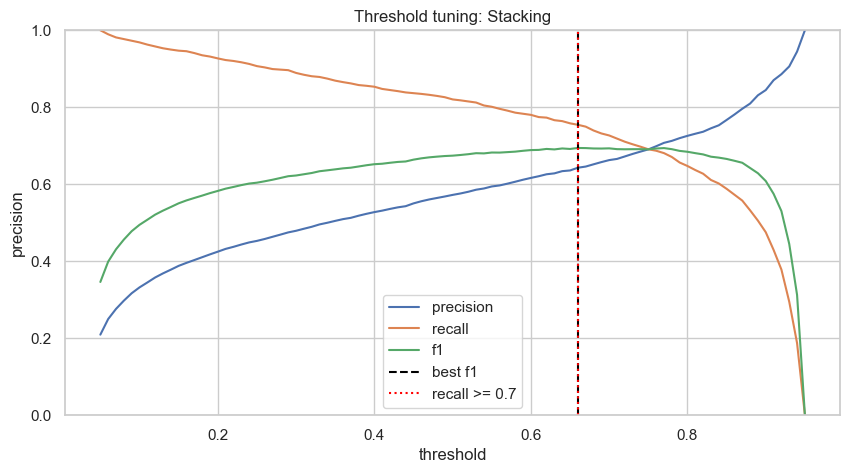

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.66,0.8609,0.642915,0.754419,0.694219,0.906675,0.764333


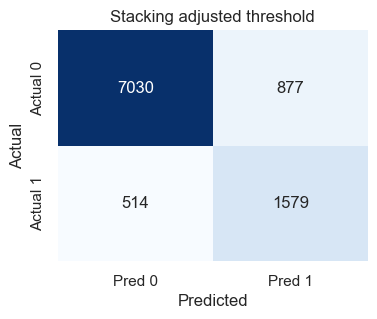

In [12]:
plt.figure(figsize=(10, 5))
for metric in ['precision', 'recall', 'f1']:
    sns.lineplot(data=threshold_result, x='threshold', y=metric, label=metric)
plt.axvline(best_f1_row['threshold'], color='black', linestyle='--', label='best f1')
plt.axvline(best_recall_row['threshold'], color='red', linestyle=':', label=f'recall >= {recall_target}')
plt.ylim(0, 1)
plt.title(f'Threshold tuning: {final_model_name}')
plt.legend()
plt.show()

selected_threshold = float(best_recall_row['threshold'])
selected_metrics = evaluate_predictions(y_test, final_scores, threshold=selected_threshold)
display(pd.DataFrame([{k: v for k, v in selected_metrics.items() if k != 'confusion_matrix'}]))

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    selected_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['Actual 0', 'Actual 1'],
    ax=ax,
)
ax.set_title(f'{final_model_name} adjusted threshold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()

**최종 판단**

- `05`에서 가장 높은 PR AUC는 Stacking의 0.7643이다.
- `04`의 Logistic Regression 기준 PR AUC 0.7631과 비교하면 개선 폭은 약 0.0012로 매우 작다.
- Soft Voting도 PR AUC 0.7639로 소폭 개선했지만, 마찬가지로 큰 차이는 아니다.
- threshold 조정 후 Stacking의 f1은 0.6942로 개선되며, 이 지점이 `05`의 최종 운영 후보로 볼 만하다.
- 하지만 모델 복잡도까지 고려하면 결론은 두 갈래로 정리하는 것이 좋다.

실무적이고 설명 가능한 최종안:

- `LogisticRegression_GridSearch`
- 장점: 성능이 거의 최상위권, recall 높음, 해석 쉬움, 실행 빠름
- 적합한 메시지: “단순한 모델이지만 churn 패턴을 충분히 잘 포착했다.”

성능 우선 최종안:

- `Stacking` + threshold 0.66
- 장점: PR AUC와 ROC AUC가 가장 높고, threshold 조정 후 f1이 가장 좋음
- 단점: 학습 시간이 길고 설명 복잡도가 높음
- 적합한 메시지: “앙상블로 소폭 개선은 가능하지만, 개선 폭은 제한적이다.”

따라서 발표나 포트폴리오에서는 `LogisticRegression`을 강한 기준 모델로 제시하고, `Stacking`은 성능 개선 실험의 최종 후보로 제시하는 구성이 가장 설득력 있다.

## 10. Risk Score 저장

`06_churn_model_interpretation_action.ipynb`에서는 모델을 다시 학습하지 않고, 여기서 저장한 test set 예측 결과만 읽어 decile/lift/action 분석을 수행한다.

저장하는 파일은 다음과 같다.

- `outputs/churn_risk_scores_test.csv`: test 고객별 원본 피처, 실제 churn, 예측 churn probability, 선택 threshold 예측값, cluster label
- `outputs/churn_model_final_result.csv`: 최종 후보 모델별 holdout 성능
- `outputs/churn_threshold_result.csv`: threshold별 precision/recall/f1 trade-off

cluster label은 데이터 누수를 막기 위해 train 데이터에서만 KMeans를 fit하고 test 데이터에는 predict만 적용한다.

In [13]:
from sklearn.cluster import KMeans

output_dir = Path('../outputs') if Path('../data').exists() else Path('outputs')
output_dir.mkdir(parents=True, exist_ok=True)

cluster_feature_cols = [
    'age',
    'account_age_months',
    'subscription_type',
    'payment_method',
    'primary_device',
    'favorite_genre',
    'time_of_day',
    'recommendation_source',
    'session_count',
    'avg_watch_time_minutes_per_week',
    'watch_sessions_per_week',
    'completion_rate',
    'avg_rating_given',
    'app_rating',
    'recommendation_click_rate',
    'days_since_last_login',
]
cluster_numeric_features = X_train[cluster_feature_cols].select_dtypes(include='number').columns.tolist()
cluster_categorical_features = X_train[cluster_feature_cols].select_dtypes(include=['object', 'string', 'category']).columns.tolist()
cluster_preprocessor = build_preprocessor(cluster_numeric_features, cluster_categorical_features)

X_train_cluster = cluster_preprocessor.fit_transform(X_train[cluster_feature_cols])
X_test_cluster = cluster_preprocessor.transform(X_test[cluster_feature_cols])

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_train_cluster)
test_cluster_labels = kmeans.predict(X_test_cluster).astype(str)

risk_output = X_test.copy()
risk_output.insert(0, 'user_id', df.loc[X_test.index, 'user_id'].values)
risk_output['actual_churn'] = y_test.values
risk_output['churn_probability'] = final_scores
risk_output['selected_threshold'] = selected_threshold
risk_output['selected_prediction'] = (final_scores >= selected_threshold).astype(int)
risk_output['final_model'] = final_model_name
risk_output['cluster'] = test_cluster_labels
risk_output = risk_output.sort_values('churn_probability', ascending=False).reset_index(drop=True)
risk_output['risk_rank'] = np.arange(1, len(risk_output) + 1)

risk_score_path = output_dir / 'churn_risk_scores_test.csv'
final_result_path = output_dir / 'churn_model_final_result.csv'
threshold_result_path = output_dir / 'churn_threshold_result.csv'

risk_output.to_csv(risk_score_path, index=False)
final_result.sort_values(['pr_auc', 'f1', 'recall'], ascending=False).to_csv(final_result_path)
threshold_result.to_csv(threshold_result_path, index=False)

print('Saved risk scores:', risk_score_path)
print('Saved final model result:', final_result_path)
print('Saved threshold result:', threshold_result_path)
display(risk_output.head())

Saved risk scores: ../outputs/churn_risk_scores_test.csv
Saved final model result: ../outputs/churn_model_final_result.csv
Saved threshold result: ../outputs/churn_threshold_result.csv


,user_id,age,gender,region,subscription_type,payment_method,primary_device,account_age_months,favorite_genre,time_of_day,...,app_rating,recommendation_click_rate,days_since_last_login,actual_churn,churn_probability,selected_threshold,selected_prediction,final_model,cluster,risk_rank
0,N23544,23,Male,Asia,Basic,Credit Card,Mobile,21,Horror,Afternoon,...,3,2,60,1,0.950002,0.66,1,Stacking,1,1
1,N31796,21,Male,South America,Basic,Gift Card,Laptop,26,Drama,Night,...,3,14,45,1,0.949849,0.66,1,Stacking,1,2
2,N18086,33,Female,North America,Basic,Credit Card,Mobile,7,Drama,Night,...,3,0,53,1,0.949826,0.66,1,Stacking,1,3
3,N34912,31,Male,Europe,Basic,Paypal,Mobile,9,Action,Morning,...,3,1,47,1,0.949816,0.66,1,Stacking,1,4
4,N08522,43,Male,North America,Basic,Debit Card,Mobile,31,Documentary,Afternoon,...,3,15,60,1,0.949784,0.66,1,Stacking,1,5


## 11. 정리

`05`의 목적은 `04`에서 만든 baseline을 튜닝과 앙상블로 실질적으로 개선할 수 있는지 확인하는 것이었다.

결과적으로 성능 순위는 PR AUC 기준으로 다음과 같이 정리된다.

- Stacking: 0.7643
- Soft Voting: 0.7639
- XGBoost RandomizedSearch: 0.7637
- Logistic Regression GridSearch: 0.7631
- LightGBM RandomizedSearch: 0.7587

가장 높은 값은 Stacking이지만, Logistic Regression 대비 개선 폭은 약 0.001 수준이다. 따라서 “복잡한 모델이 압도적으로 좋다”는 결론은 아니다. 오히려 이 데이터에서는 최근 로그인 공백, 시청량, 완료율, 추천 클릭률 같은 행동 신호가 선형 모델만으로도 충분히 잘 잡히는 것으로 해석할 수 있다.

최종 운영 후보는 목적에 따라 다르게 선택할 수 있다.

- 설명력과 실행 효율을 중시하면 `LogisticRegression_GridSearch`가 적합하다.
- 지표상 최고 성능을 중시하면 `Stacking`이 적합하다.
- 실무 적용 시에는 Stacking을 threshold 0.66으로 조정하면 f1 0.6942, recall 0.7544, precision 0.6429의 균형점을 얻을 수 있다.

따라서 이 프로젝트의 모델링 결론은 다음과 같이 잡는 것이 좋다.

> 기본 모델링에서는 Logistic Regression이 강한 기준선을 만들었고, 튜닝/앙상블을 통해 Stacking이 PR AUC를 소폭 개선했다. 다만 개선 폭이 작으므로, 최종 선택은 성능뿐 아니라 해석 가능성, 실행 비용, 캠페인 운영 목적을 함께 고려해야 한다.
